### Ejercicio 3 - Construcción de la matriz de proyección binaria


In [8]:
import numpy as np

# La función devuelve una imagen binaria que indica por dónde pasa un rayo
def mascara_rayo(n, direccion, s):
    alpha, beta = direccion
    
    M = np.zeros((n, n), dtype=int) #crea una matriz llena de ceros.
    
    for i in range(n):
        for j in range(n): # recorre todos los píxeles.
            if alpha*i + beta*j == s:
                M[i, j] = 1 #marca con 1 los que cumplen la ecuación.
    
    return M

En lugar de trabajar con un solo rayo, queremos reunir muchos rayos dentro de una única matriz llamada $A$. Cada máscara se vectoriza y se agrega como una fila de la matriz.

Esta matriz la denominamos ``Matriz de proyección``

In [9]:
#Inciso a) y b)

def matriz_proyeccion(n, direcciones):
    # n= Tamaño de la imagen
    filas_A = []
    rayos = []

    for alpha, beta in direcciones:

        # Calcular todos los valores posibles de s = alpha*i + beta*j
        valores_s = {
            alpha * i + beta * j
            for i in range(n)
            for j in range(n)
        }

        # Recorrer los valores de s de menor a mayor
        for s in sorted(valores_s):

            # Construir la máscara correspondiente al rayo
            M = mascara_rayo(n, (alpha, beta), s)

            # Convertir la máscara n×n en un vector de longitud n²
            fila = M.flatten()

            # Agregar el vector como una nueva fila de A
            filas_A.append(fila)

            # Información asociada a esa misma fila
            rayos.append(((alpha, beta), s))

    # Convertir la lista de filas en una matriz de NumPy
    A = np.array(filas_A, dtype=int)

    return A, rayos

Guardamos, junto con la matriz $A$, la dirección $(\alpha,\beta)$ y el desplazamiento $s$ correspondientes a cada una de sus filas. 

Cuando construimos $A$, cada máscara se transforma en una fila. Sin embargo, si solamente guardamos la matriz, vemos filas de ceros y unos, pero perdemos una identificación directa de qué dirección $(\alpha,\beta)$ y qué desplazamiento $s$ generaron cada fila.


### c) 
Queremos construir la matriz de proyección usando rayos horizontales y verticales, y verificar que se obtienen 16 rayos y una matriz de dimensiones $16\times64$.

In [10]:
# Inciso c)
n = 8
direcciones = [(1, 0), (0, 1)]

A, rayos = matriz_proyeccion(n, direcciones)

print("Rayos obtenidos:")
for k, rayo in enumerate(rayos):
    print(f"Fila {k}: {rayo}")

print("")
print("Cantidad de rayos:", len(rayos))
print("Dimensiones de A:", A.shape)


Rayos obtenidos:
Fila 0: ((1, 0), 0)
Fila 1: ((1, 0), 1)
Fila 2: ((1, 0), 2)
Fila 3: ((1, 0), 3)
Fila 4: ((1, 0), 4)
Fila 5: ((1, 0), 5)
Fila 6: ((1, 0), 6)
Fila 7: ((1, 0), 7)
Fila 8: ((0, 1), 0)
Fila 9: ((0, 1), 1)
Fila 10: ((0, 1), 2)
Fila 11: ((0, 1), 3)
Fila 12: ((0, 1), 4)
Fila 13: ((0, 1), 5)
Fila 14: ((0, 1), 6)
Fila 15: ((0, 1), 7)

Cantidad de rayos: 16
Dimensiones de A: (16, 64)


### d) Interpretación de las filas y columnas de la matriz de proyección

La matriz de proyección es:

$$
A \in \mathbb{R}^{16 \times 64}.
$$

Las 16 filas corresponden a los 16 rayos utilizados: 8 rayos horizontales, asociados a la dirección $(1,0)$, y 8 rayos verticales, asociados a la dirección $(0,1)$.

Cada fila de $A$ representa un rayo. Los valores de esa fila indican cuáles de los 64 píxeles del fantoma son atravesados por dicho rayo:

- Un valor igual a `1` indica que el rayo atraviesa ese píxel.
- Un valor igual a ``0`` indica que el rayo no atraviesa ese píxel.

Por ejemplo, la fila asociada al rayo $((1,0),0)$ representa el rayo horizontal que atraviesa la primera fila del fantoma. Como esa fila contiene 8 píxeles, la fila correspondiente de $A$ tiene 8 unos y 56 ceros.

Por otra parte, cada columna de $A$ representa uno de los 64 píxeles del fantoma de tamaño $8 \times 8$. Al vectorizar el fantoma, los píxeles quedan ordenados de la siguiente manera:

$$
(0,0), (0,1), \ldots, (0,7), (1,0), \ldots, (7,7).
$$

Por lo tanto, la columna $k$ muestra qué rayos atraviesan el píxel asociado a esa posición. En este caso, cada píxel es atravesado por exactamente dos rayos: un rayo horizontal y un rayo vertical. Por eso, cada columna de $A$ contiene dos unos y catorce ceros.

La matriz contiene una gran cantidad de ceros porque cada rayo atraviesa solamente una pequeña parte del fantoma. Un rayo horizontal o vertical atraviesa 8 de los 64 píxeles.

Al visualizar $A$, cada fila de la imagen representa un rayo y cada columna representa un píxel. Las posiciones claras corresponden a valores iguales a $1$, mientras que las posiciones oscuras corresponden a valores iguales a $0$.

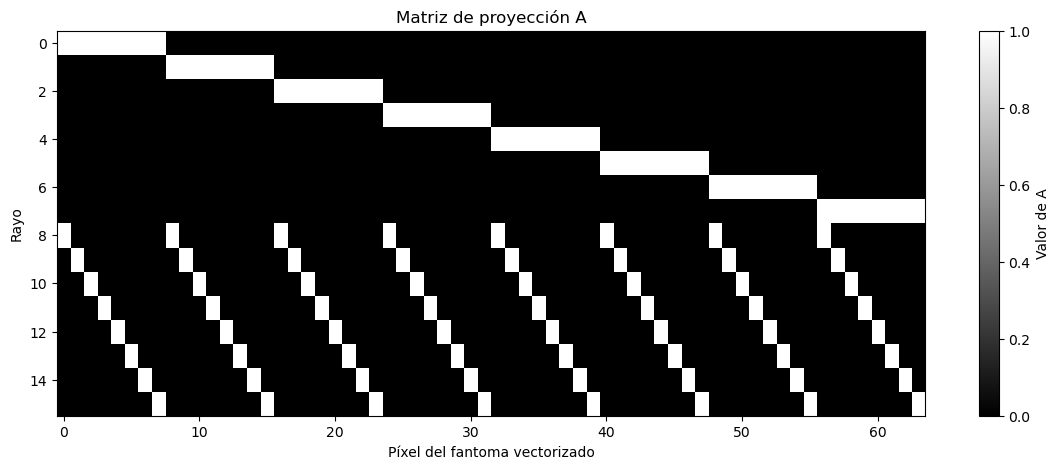

In [11]:
import matplotlib.pyplot as plt

# Inciso d)
plt.figure(figsize=(14, 5))

plt.imshow(
    A,
    cmap="gray",
    vmin=0,
    vmax=1,
    aspect="auto"
)

plt.colorbar(label="Valor de A")
plt.xlabel("Píxel del fantoma vectorizado")
plt.ylabel("Rayo")
plt.title("Matriz de proyección A")

plt.show()

### e) Cálculo de las mediciones

Queremos calcular el vector de mediciones

$$
b = A x_{\text{fantoma}},
$$

verificamos que sus primeros ocho valores son las sumas de las filas del fantoma y que los últimos ocho son las sumas de sus columnas.

In [12]:
# Vectorizar el fantoma de 8×8
X_fantoma = np.array([
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

xfantoma = X_fantoma.reshape(-1)

# Calcular las mediciones
b = A @ xfantoma

# Separar los dos bloques
b_filas = b[:8]
b_columnas = b[8:]

# Sumas directas del fantoma
sumas_filas = X_fantoma.sum(axis=1) #sumo las filas, osea horizontalmente
sumas_columnas = X_fantoma.sum(axis=0) #sumo las columnas, osea verticalmente

print("Forma de xfantoma:", xfantoma.shape)
print("Forma de A:", A.shape)
print("Forma de b:", b.shape)

print("\nPrimeras ocho mediciones:")
print(b_filas)

print("\nSuma de las filas del fantoma:")
print(sumas_filas)

print("\nÚltimas ocho mediciones:")
print(b_columnas)

print("\nSuma de las columnas del fantoma:")
print(sumas_columnas)

# Verificaciones numéricas
assert np.allclose(b_filas, sumas_filas)
assert np.allclose(b_columnas, sumas_columnas)

print("\nLas verificaciones son correctas.")

Forma de xfantoma: (64,)
Forma de A: (16, 64)
Forma de b: (16,)

Primeras ocho mediciones:
[0.  1.7 3.3 2.3 2.  2.4 1.4 0. ]

Suma de las filas del fantoma:
[0.  1.7 3.3 2.3 2.  2.4 1.4 0. ]

Últimas ocho mediciones:
[0.  1.7 3.3 2.3 2.  2.4 1.4 0. ]

Suma de las columnas del fantoma:
[0.  1.7 3.3 2.3 2.  2.4 1.4 0. ]

Las verificaciones son correctas.


Las mediciones tomográficas se calculan mediante el producto

$$
b=A\,x_{\text{fantoma}},
$$

donde $A\in\mathbb{R}^{16\times64}$ es la matriz de proyección y
$x_{\text{fantoma}}\in\mathbb{R}^{64}$ es la versión vectorizada del
fantoma de tamaño $8\times8$.

Por lo tanto, el vector resultante tiene dimensiones

$$
b\in\mathbb{R}^{16}.
$$

Cada componente de $b$ representa la suma de los valores de atenuación
de los píxeles atravesados por un rayo.

Las primeras ocho filas de $A$ corresponden a la dirección $(1,0)$.
Estos rayos son horizontales y cada uno atraviesa una fila completa del
fantoma. Por esta razón, las primeras ocho componentes de $b$ coinciden
con

$$
X_{\text{fantoma}}.\operatorname{sum}(\text{axis}=1).
$$

Es decir,

$$
b_k=\sum_{j=0}^{7}(X_{\text{fantoma}})_{k,j},
\qquad k=0,\ldots,7.
$$

Las últimas ocho filas de $A$ corresponden a la dirección $(0,1)$.
Estos rayos son verticales y cada uno atraviesa una columna completa del
fantoma. Por lo tanto, las últimas ocho componentes de $b$ coinciden con

$$
X_{\text{fantoma}}.\operatorname{sum}(\text{axis}=0).
$$

En este caso,

$$
b_{8+k}=\sum_{i=0}^{7}(X_{\text{fantoma}})_{i,k},
\qquad k=0,\ldots,7.
$$

La igualdad se verifica numéricamente utilizando `np.allclose`.

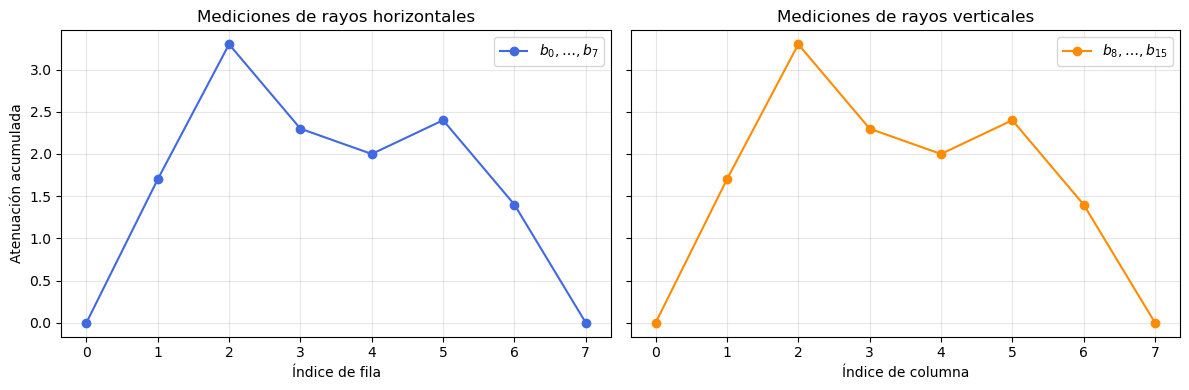

In [13]:
indices = np.arange(8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Primer bloque: rayos horizontales
axes[0].plot(
    indices,
    b_filas,
    marker="o",
    linestyle="-",
    color="royalblue",
    label=r"$b_0,\ldots,b_7$"
)

axes[0].set_title("Mediciones de rayos horizontales")
axes[0].set_xlabel("Índice de fila")
axes[0].set_ylabel("Atenuación acumulada")
axes[0].set_xticks(indices)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Segundo bloque: rayos verticales
axes[1].plot(
    indices,
    b_columnas,
    marker="o",
    linestyle="-",
    color="darkorange",
    label=r"$b_8,\ldots,b_{15}$"
)

axes[1].set_title("Mediciones de rayos verticales")
axes[1].set_xlabel("Índice de columna")
axes[1].set_xticks(indices)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

El primer gráfico muestra las mediciones producidas por los ocho rayos horizontales y el segundo muestra las mediciones producidas por los ocho rayos verticales.

``Ambos gráficos son iguales`` porque el fantoma es una matriz simétrica:

$$
X_{\text{fantoma}} = X_{\text{fantoma}}^T
$$

Esto significa que cada fila contiene los mismos valores que la columna correspondiente. Por lo tanto, la suma de la fila $k$ coincide con la suma de la columna $k$:

$$
\sum_j X_{kj} = \sum_i X_{ik}
$$

En consecuencia, los rayos horizontales y verticales producen las mismas mediciones para este fantoma. Esto no ocurre necesariamente con cualquier imagen, sino que se debe a la simetría particular de $X_{\text{fantoma}}$.